In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

import warnings 
warnings.filterwarnings("ignore")

In [2]:
torch.manual_seed(42)
np.random.seed(42)

In [3]:
df = pd.read_csv(r"C:\Users\prati\Downloads\monthly_milk_production.csv")

In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print(df.head())
print(df.describe())

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
       Production
count  168.000000
mean   754.708333
std    102.204524
min    553.000000
25%    677.750000
50%    761.000000
75%    824.500000
max    969.000000


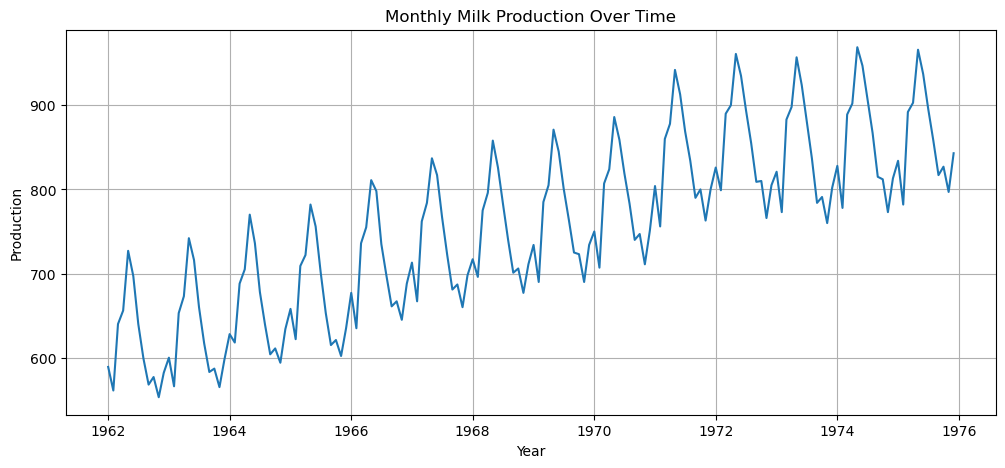

In [5]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Production'])
plt.title("Monthly Milk Production Over Time")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(True)
plt.show()

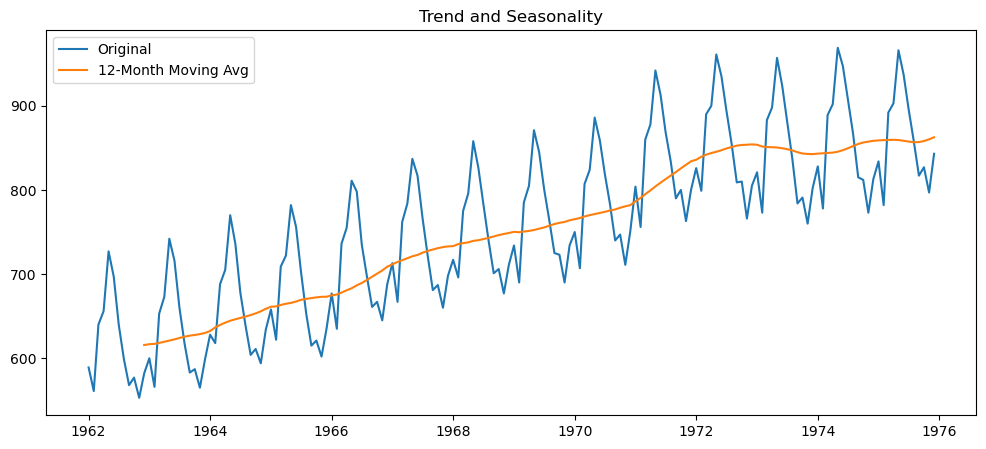

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df['Production'], label='Original')
plt.plot(df['Production'].rolling(12).mean(), label='12-Month Moving Avg')
plt.title("Trend and Seasonality")
plt.legend()
plt.show()

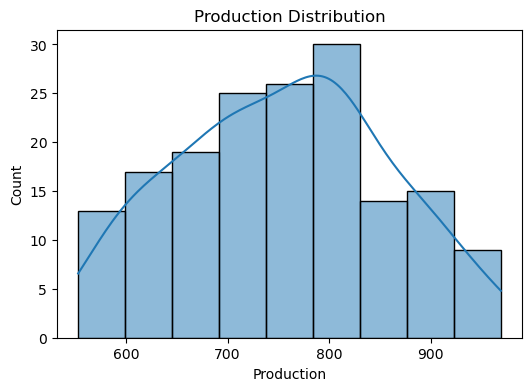

Missing values:
 Production    0
dtype: int64


In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df['Production'], kde=True)
plt.title("Production Distribution")
plt.show()

# Missing values
print("Missing values:\n", df.isnull().sum())

In [8]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df[['Production']])

In [9]:
def create_sequences(data, window=12):
    X, y = [], []
    for i in range(len(data)-window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

window_size = 12
X, y = create_sequences(scaled_data, window_size)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (156, 12, 1)
y shape: (156, 1)


In [10]:
train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.15)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size+val_size]
y_val = y[train_size:train_size+val_size]

X_test = X[train_size+val_size:]
y_test = y[train_size+val_size:]

In [11]:
train_data = TensorDataset(
    torch.FloatTensor(X_train),
    torch.FloatTensor(y_train)
)

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)


In [12]:
class ForecastModel(nn.Module):
    def __init__(self, model_type="RNN", hidden_size=32):
        super().__init__()

        if model_type == "RNN":
            self.rnn = nn.RNN(1, hidden_size, batch_first=True)
        elif model_type == "LSTM":
            self.rnn = nn.LSTM(1, hidden_size, batch_first=True)
        else:
            self.rnn = nn.GRU(1, hidden_size, batch_first=True)

        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

In [13]:
def train_model(model, epochs=50):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            pred = model(X_batch)
            loss = criterion(pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch+1) % 10 == 0:
            print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

    return model

In [14]:
print("\nTraining RNN...")
rnn_model = train_model(ForecastModel("RNN"))

print("\nTraining LSTM...")
lstm_model = train_model(ForecastModel("LSTM"))

print("\nTraining GRU...")
gru_model = train_model(ForecastModel("GRU"))


Training RNN...
Epoch 10, Loss: 0.1981
Epoch 20, Loss: 0.1342
Epoch 30, Loss: 0.0997
Epoch 40, Loss: 0.0791
Epoch 50, Loss: 0.0588

Training LSTM...
Epoch 10, Loss: 0.2222
Epoch 20, Loss: 0.1887
Epoch 30, Loss: 0.1520
Epoch 40, Loss: 0.1273
Epoch 50, Loss: 0.1053

Training GRU...
Epoch 10, Loss: 0.1811
Epoch 20, Loss: 0.1262
Epoch 30, Loss: 0.0836
Epoch 40, Loss: 0.0377
Epoch 50, Loss: 0.0298


In [15]:
def evaluate(model, X_test, y_test):
    model.eval()

    with torch.no_grad():
        preds = model(torch.FloatTensor(X_test)).numpy()

    preds = scaler.inverse_transform(preds)
    y_true = scaler.inverse_transform(y_test)

    rmse = np.sqrt(mean_squared_error(y_true, preds))
    mae = mean_absolute_error(y_true, preds)
    mape = np.mean(np.abs((y_true - preds) / y_true)) * 100

    return preds, y_true, rmse, mae, mape

In [16]:
rnn_preds, y_true, rnn_rmse, rnn_mae, rnn_mape = evaluate(rnn_model, X_test, y_test)
lstm_preds, _, lstm_rmse, lstm_mae, lstm_mape = evaluate(lstm_model, X_test, y_test)
gru_preds, _, gru_rmse, gru_mae, gru_mape = evaluate(gru_model, X_test, y_test)

print("\nModel Performance:")
print("RNN  -> RMSE:", rnn_rmse, "MAE:", rnn_mae, "MAPE:", rnn_mape)
print("LSTM -> RMSE:", lstm_rmse, "MAE:", lstm_mae, "MAPE:", lstm_mape)
print("GRU  -> RMSE:", gru_rmse, "MAE:", gru_mae, "MAPE:", gru_mape)



Model Performance:
RNN  -> RMSE: 40.91738432794421 MAE: 35.185091654459626 MAPE: 4.0765442700693555
LSTM -> RMSE: 55.570483361507314 MAE: 44.99044545491537 MAPE: 5.100965887116081
GRU  -> RMSE: 33.565927615870294 MAE: 26.115814208984364 MAPE: 3.0870463694862886


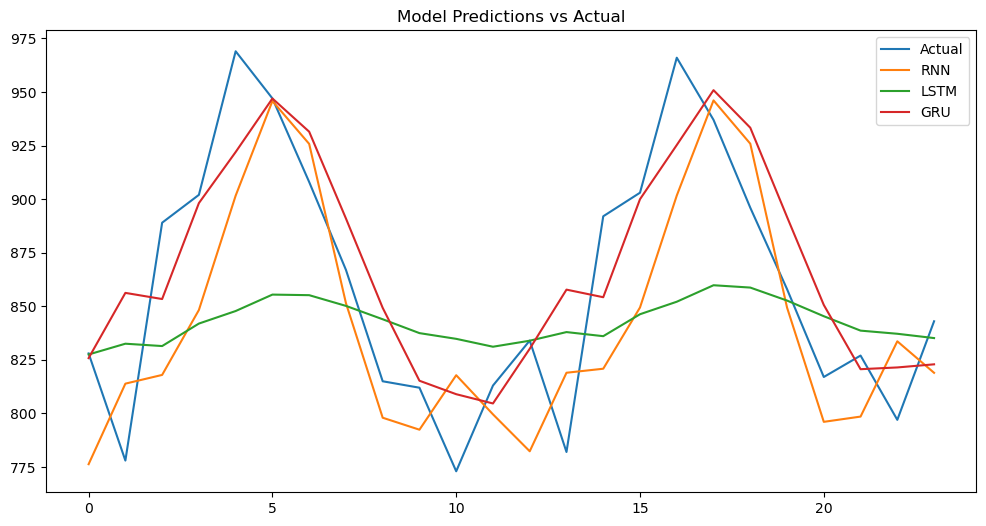

In [17]:
plt.figure(figsize=(12,6))
plt.plot(y_true, label="Actual")
plt.plot(rnn_preds, label="RNN")
plt.plot(lstm_preds, label="LSTM")
plt.plot(gru_preds, label="GRU")
plt.title("Model Predictions vs Actual")
plt.legend()
plt.show()

In [18]:
def forecast_future(model, last_window, steps=12):
    model.eval()
    future = []

    current = last_window.copy()

    for _ in range(steps):
        with torch.no_grad():
            pred = model(torch.FloatTensor(current).unsqueeze(0)).numpy()

        future.append(pred[0])
        current = np.vstack((current[1:], pred))

    return scaler.inverse_transform(np.array(future))

future_forecast = forecast_future(lstm_model, X[-1])

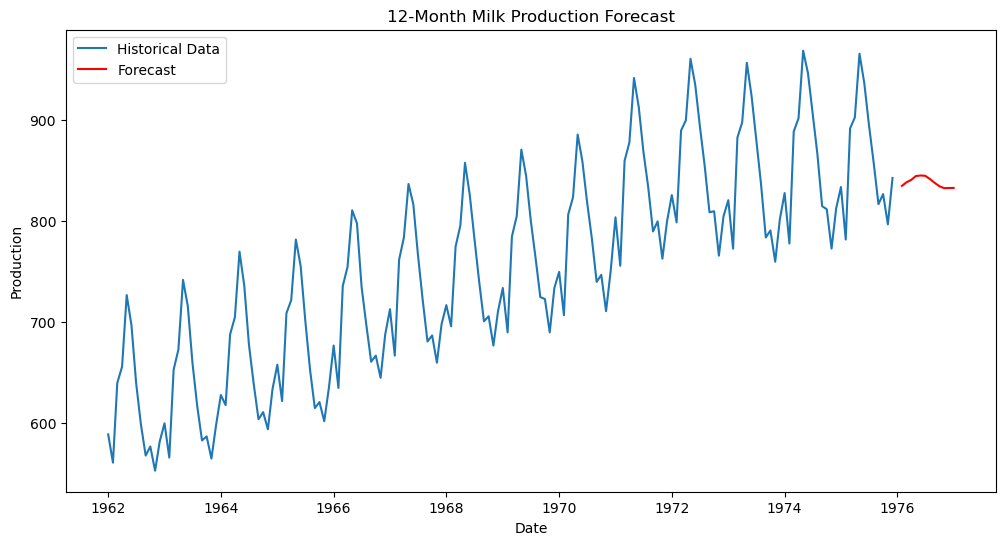

In [19]:
plt.figure(figsize=(12,6))
plt.plot(df['Production'], label="Historical Data")

future_dates = pd.date_range(
    start=df.index[-1],
    periods=13,
    freq='M'
)[1:]

plt.plot(future_dates, future_forecast, label="Forecast", color='red')

plt.title("12-Month Milk Production Forecast")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()

In [20]:
print("""Model Evaluation and Comparison
Three deep learning models — RNN, LSTM, and GRU — were evaluated using RMSE, MAE, and MAPE metrics.
The GRU model achieved the best performance with the lowest error values:

RMSE: 33.57

MAE: 26.12

MAPE: 3.09%

This indicates that GRU provides the most accurate predictions for monthly milk production. The LSTM model performed worse than both RNN and GRU, likely due to overfitting and the relatively small dataset size.
GRU’s simpler architecture allows it to efficiently capture temporal dependencies without excessive model complexity.

Business Insights from Results

Now let’s connect this to business value:

Business Implications
1. Accurate Demand Planning
With only 3% prediction error, the dairy company can:
Predict production reliably
Reduce surplus or shortages
Improve demand matching

2. Seasonal Production Optimization
GRU captures seasonal peaks, enabling:
Better inventory storage planning
Efficient cold chain management

3. Cost Reduction
Improved forecasting leads to:
Reduced waste
Better workforce scheduling
Lower operational costs

4. Strategic Decision Making
The company can:
Plan expansion
Optimize logistics
Improve supply chain resilience

Why LSTM Performed Worse (Important Insight)
This is a great discussion point for your assignment:

Possible reasons:
Dataset is relatively small
LSTM has more parameters → overfitting risk
Training epochs may be insufficient
Hyperparameters not optimized
GRU is often better for medium-sized time series datasets.

Conclusion
Among the three deep learning models tested, the GRU model demonstrated superior performance in forecasting monthly milk production. With the lowest RMSE, MAE, and MAPE values, GRU provides highly accurate predictions suitable for real-world operational planning.
The results suggest that GRU is the most appropriate model for this forecasting task. Its ability to capture seasonal patterns with minimal error enables the dairy business to make informed decisions regarding inventory management, workforce allocation, and supply chain optimization.
Future work may involve hyperparameter tuning and hybrid models to further improve forecasting accuracy.""")

Model Evaluation and Comparison
Three deep learning models — RNN, LSTM, and GRU — were evaluated using RMSE, MAE, and MAPE metrics.
The GRU model achieved the best performance with the lowest error values:

RMSE: 33.57

MAE: 26.12

MAPE: 3.09%

This indicates that GRU provides the most accurate predictions for monthly milk production. The LSTM model performed worse than both RNN and GRU, likely due to overfitting and the relatively small dataset size.
GRU’s simpler architecture allows it to efficiently capture temporal dependencies without excessive model complexity.

Business Insights from Results

Now let’s connect this to business value:

Business Implications
1. Accurate Demand Planning
With only 3% prediction error, the dairy company can:
Predict production reliably
Reduce surplus or shortages
Improve demand matching

2. Seasonal Production Optimization
GRU captures seasonal peaks, enabling:
Better inventory storage planning
Efficient cold chain management

3. Cost Reduction
Impro